#Step 1: Imports and loading the data

In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv("tips.csv")

print(df.head())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [39]:
print(df.describe())

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


#Step 2: Visualizing relationships

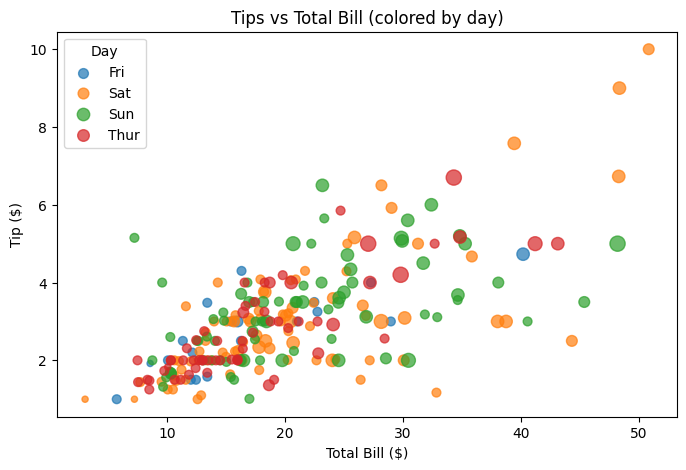

In [40]:
import matplotlib.pyplot as plt

# 1. Scatter: tip vs total_bill, colored by day
fig, ax = plt.subplots(figsize=(8,5))
for day, group in df.groupby("day"):
    ax.scatter(group["total_bill"], group["tip"], s=group["size"]*20, label=day, alpha=0.7)
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Tips vs Total Bill (colored by day)")
ax.legend(title="Day")
plt.show()


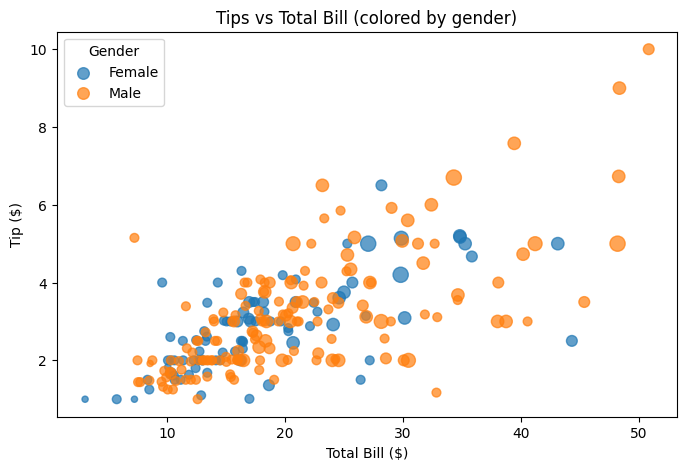

In [41]:
# 2. Scatter: tip vs total_bill, colored by sex
fig, ax = plt.subplots(figsize=(8,5))
for sex, group in df.groupby("sex"):
    ax.scatter(group["total_bill"], group["tip"], s=group["size"]*20, label=sex, alpha=0.7)
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Tips vs Total Bill (colored by gender)")
ax.legend(title="Gender")
plt.show()

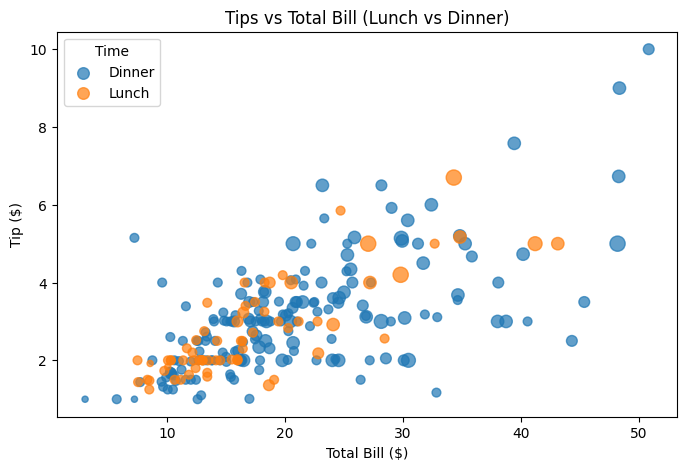

In [42]:
# 3. Scatter: tip vs total_bill, colored by time
fig, ax = plt.subplots(figsize=(8,5))
for time, group in df.groupby("time"):
    ax.scatter(group["total_bill"], group["tip"], s=group["size"]*20, label=time, alpha=0.7)
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Tips vs Total Bill (Lunch vs Dinner)")
ax.legend(title="Time")
plt.show()

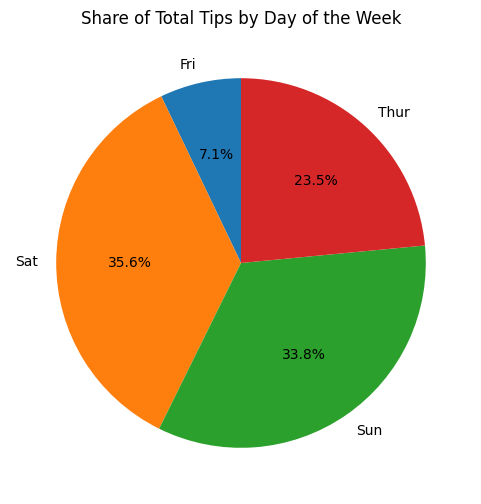

In [43]:
# 4. Pie: tip share by day
fig, ax = plt.subplots(figsize=(6,6))
tip_by_day = df.groupby("day")["tip"].sum()
ax.pie(tip_by_day, labels=tip_by_day.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Share of Total Tips by Day of the Week")
plt.show()


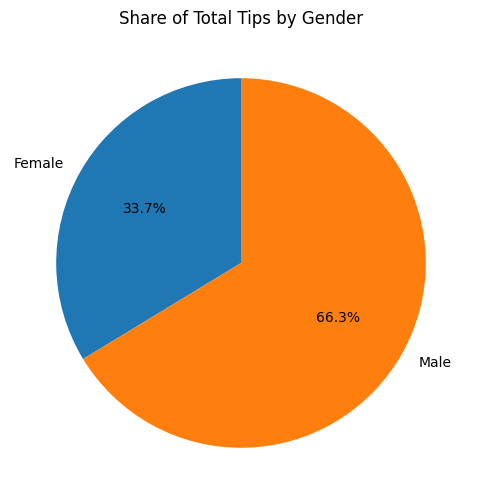

In [44]:
# 5. Pie: tip share by sex
fig, ax = plt.subplots(figsize=(6,6))
tip_by_sex = df.groupby("sex")["tip"].sum()
ax.pie(tip_by_sex, labels=tip_by_sex.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Share of Total Tips by Gender")
plt.show()


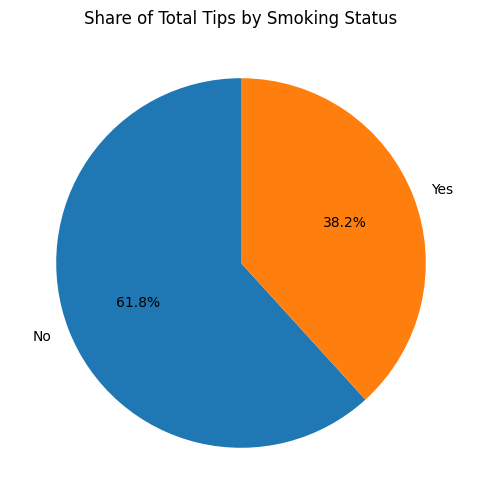

In [45]:
# 6. Pie: tip share by smoker
fig, ax = plt.subplots(figsize=(6,6))
tip_by_smoker = df.groupby("smoker")["tip"].sum()
ax.pie(tip_by_smoker, labels=tip_by_smoker.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Share of Total Tips by Smoking Status")
plt.show()

#Step 3: Encoding categorical features

In [46]:
# Map categorical columns to numeric codes
df["sex"] = df["sex"].map({"Female": 0, "Male": 1})
df["smoker"] = df["smoker"].map({"No": 0, "Yes": 1})
df["day"] = df["day"].map({"Thur": 0, "Fri": 1, "Sat": 2, "Sun": 3})
df["time"] = df["time"].map({"Lunch": 0, "Dinner": 1})

print(df.head())

   total_bill   tip  sex  smoker  day  time  size
0       16.99  1.01    0       0    3     1     2
1       10.34  1.66    1       0    3     1     3
2       21.01  3.50    1       0    3     1     3
3       23.68  3.31    1       0    3     1     2
4       24.59  3.61    0       0    3     1     4


#Step 4: Splitting the data

In [47]:
from sklearn.model_selection import train_test_split

x = df[["total_bill", "sex", "smoker", "day", "time", "size"]]
y = df["tip"]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

#Step 5: Training the model

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(xtrain, ytrain)

LinearRegression()

#Step 6: Evaluating and predicting

In [49]:
score = model.score(xtest, ytest)
print("R² score on test set:", round(score, 4))

features = pd.DataFrame([[24.50, 1, 0, 2, 1, 4]], columns=x.columns)
pred = model.predict(features)
print("Predicted tip:", round(pred[0], 2))

R² score on test set: 0.4429
Predicted tip: 3.87
